In [33]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, nltk, os, glob
from utils import plot_style; plot_style()
import torch

In [34]:
def norm01(x): return (x - np.min(x)) / (np.max(x) - np.min(x))

### Objective


### Plan
1.0 Data & Model
* Load story_data as df from TableS4. Show story_data.head().
* Create story2text mapping story number to text concatenated across all rows with that story number. Assert 16 stories. Show example mapping.
* Load Llama or Qwen. Print relevant details.

2.1 Memory recall behavior
* Loop over stories (for now, can break after 1st story, story 11) and have model output to interim_data/narrative/event_summary.filetype* the 1) locational and 2) social information gained in terms of 4-6 events each. Consider example outputs for story 11.
    * Locational: Bell-on-door entry → a restaurant Thomas picked → styled as a '70s diner (checkerboard floor, red leather booths, long bar) → staffed, with a back booth section → bar patrons nearby, within earshot.
    * Social: Thomas planned this breakup for 2 months (one-sided) → Sadie arrives warm and unaware → Thomas ends it, blaming his career → Sadie grieves, then bargains → his silence makes it final → Sadie turns angry, cuts contact, demands her stuff back.

2.2 Sentence predictions
* Create dicts location_graph and social_graph, whose values are also dicts ev1, ev2.., whose values are lists of sentences within that event and schema (e.g., the 70s diner description event within the location schema).
* Lane plot: with sentence number on x, events along y, ordered first by schema and then event number. If a sentence appears in an event, color the corresponding cell, else white. Also add ground-truth event boundaries as the diffs along locationEvent and socialEvent in TableS4.


### Note to AI
* each bullet should have a corresponding markdown+code
* in-line asterisk denotes that your inputs are welcome


### 1. Data & Model

In [35]:
story_data = pd.read_csv('../../input_data/narrative/TableS4.csv')
story_data[['story', 'storyText']].head()

,story,storyText
0,11,"A bell chimed as the door swung open, and Sadi..."
1,11,Thomas had been thinking about breaking up wit...
2,11,The restaurant he had chosen to meet at was re...
3,11,There was black and white checkerboard tiling ...
4,11,"Thomas stood up and gave Sadie a side hug, ask..."


In [36]:
# create story2text, which, for each unique story val, maps text that is concatenated across rows with that story val
story2text = story_data.groupby('story')['storyText'].apply(lambda x: ' '.join(x)).to_dict()
print(f'#stories: {len(story2text)}')
print(f'story2text example: {list(story2text.items())[0]}')

#stories: 16
story2text example: (11, 'A bell chimed as the door swung open, and Sadie entered to find Thomas, who was dreading the approaching breakup conversation he was about to start, ruminating at the bar. Thomas had been thinking about breaking up with her for 2 months now. The restaurant he had chosen to meet at was reminiscent of a diner from the 70’s. There was black and white checkerboard tiling on the floor, a long bar in the front, and booths and stools with red, leather upholstery.  Thomas stood up and gave Sadie a side hug, asking quickly, “How was your day?” She clung onto him, “It was okay- I missed you today.” He looked away and addressed the hostess coming towards them, “Can we have a booth in the back?” She shrugged and after loudly popping her bubblegum replied, “Sure, honey.” The hostess seated them at a booth in the back corner of the diner.   Sadie slipped into the cushioned seat and grabbed Thomas’ hand. “Tell me about your day!” she sang. Thomas looked away and

In [37]:
storyIDs = story_data['story'].unique()
soc_schemas = ['break up', 'proposal', 'business deal', 'meet cute']
loc_schemas = ['restaurant', 'airport', 'grocery store', 'lecture hall']

story2schema = {}
for i in range(4):
    for j in range(4):
        story2schema[storyIDs[i*4 + j]] = (soc_schemas[i] + ' arc', loc_schemas[j] + ' description')
story2schema


{np.int64(11): ('break up arc', 'restaurant description'),
 np.int64(12): ('break up arc', 'airport description'),
 np.int64(13): ('break up arc', 'grocery store description'),
 np.int64(14): ('break up arc', 'lecture hall description'),
 np.int64(21): ('proposal arc', 'restaurant description'),
 np.int64(22): ('proposal arc', 'airport description'),
 np.int64(23): ('proposal arc', 'grocery store description'),
 np.int64(24): ('proposal arc', 'lecture hall description'),
 np.int64(31): ('business deal arc', 'restaurant description'),
 np.int64(32): ('business deal arc', 'airport description'),
 np.int64(33): ('business deal arc', 'grocery store description'),
 np.int64(34): ('business deal arc', 'lecture hall description'),
 np.int64(41): ('meet cute arc', 'restaurant description'),
 np.int64(42): ('meet cute arc', 'airport description'),
 np.int64(43): ('meet cute arc', 'grocery store description'),
 np.int64(44): ('meet cute arc', 'lecture hall description')}

In [38]:
%pip install -q transformers accelerate
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-3B"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
model = model.to(device)

model.eval() # set to evaluation mode (disable dropout, etc.)

print(f"Model loaded: {MODEL_ID}")
print(f"  Layers     : {model.config.num_hidden_layers}\n(+ 1 embedding layer at the beginning that converts raw inputs to tokens)")
print(f"  Hidden dim : {model.config.hidden_size}")


Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Using device: cpu
Model loaded: Qwen/Qwen2.5-3B
  Layers     : 36
(+ 1 embedding layer at the beginning that converts raw inputs to tokens)
  Hidden dim : 2048


### 2.1 Memory recall behavior

Use the Instruct model to extract 4–6 locational and social events per story. Events are structured narrative summaries saved as JSON for use in Section 3.

In [39]:
import json, re, os
from transformers import AutoTokenizer, AutoModelForCausalLM

# Reload as instruct variant — better at following structured output prompts than base model
MODEL_ID_INST = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer_inst = AutoTokenizer.from_pretrained(MODEL_ID_INST)
model_inst = AutoModelForCausalLM.from_pretrained(MODEL_ID_INST, torch_dtype=torch.float32).to(device)
model_inst.eval()

def extract_events(story_text, schema, n=4):
    # schema-specific task descriptions guide the model to focus on the right narrative dimension
    task = {
        'locational': (
            f"List {n} distinct LOCATION and NON-SOCIAL details as narrative descriptions — "
            f"(e.g. 'Characters enter a 70s-style diner and are seated at a back booth'). "
            f"One short phrase each."
        ),
        'social':     f"List {n} distinct SOCIAL events (shifts in character dynamics/emotion). One short phrase each.",
    }[schema]
    messages = [
        {"role": "system", "content": "You are a narrative analyst. Output ONLY a numbered list."},
        {"role": "user",   "content": f"Story:\n{story_text}\n\n{task}"},
    ]
    # apply_chat_template formats messages into the model's expected input string
    text   = tokenizer_inst.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer_inst(text, return_tensors="pt").to(device)
    with torch.no_grad():
        # greedy decoding (do_sample=False) for deterministic, reproducible output
        out = model_inst.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,
            eos_token_id=tokenizer_inst.eos_token_id,
            pad_token_id=tokenizer_inst.eos_token_id,
        )
    # decode only the newly generated tokens (skip the prompt)
    raw = tokenizer_inst.decode(out[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    # extract numbered list items e.g. "1. Bell-on-door entry" → "Bell-on-door entry"
    items = re.findall(r'^\d+\.\s+(.+)$', raw, re.MULTILINE)
    return [x.strip() for x in items]

event_summary = {}
for story_id, story_text in story2text.items():
    result = {}
    for schema in ['locational', 'social']:
        events = extract_events(story_text, schema)
        result[schema] = events
        print(f"Story {story_id} — {schema}: {events}")
    event_summary[story_id] = result
    break  # process only story 11 for now; remove break to run all 16 stories

# save event descriptions as JSON; used in Section 3 as event labels and for embedding
SAVE_PATH = "../../interim_data/narrative/event_summary.json"
with open(SAVE_PATH, 'w') as f:
    json.dump(event_summary, f, indent=2)
print(f"\nSaved → {SAVE_PATH}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Story 11 — locational: ['Restaurant: Diner', 'Hostess: Friendly and welcoming', 'Booth: Back corner', 'Menu: Laminated posters with silly names for food items']
Story 11 — social: ["Thomas' initial reluctance to discuss his feelings.", "Sadie's initial hesitation but eventual determination.", "Thomas' shift from passive to active in discussing his situation.", "Sadie's sudden realization of the importance of their relationship."]

Saved → ../../interim_data/narrative/event_summary.json


### 2.2 Sentence contributions to memory 

Assign each sentence to its most semantically similar event (per schema) using cosine similarity between sentence and event-description embeddings. `location_graph` and `social_graph` map event IDs to lists of sentences assigned to that event.

In [40]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

STORY_ID  = 11
SAVE_PATH = "../../interim_data/narrative/event_summary.json"

# load LLM-generated event descriptions from Section 2
with open(SAVE_PATH) as f:
    event_summary = json.load(f)

# story_data was loaded in Section 1 (story, storyText columns only)
sentences = story_data[story_data['story'] == STORY_ID]['storyText'].tolist()

# JSON serialisation converts int keys to strings, so access with str(STORY_ID)
loc_descs = event_summary[str(STORY_ID)]['locational']   # list of event description strings
soc_descs = event_summary[str(STORY_ID)]['social']

# embed sentences and event descriptions into the same semantic space
st_model  = SentenceTransformer('all-MiniLM-L6-v2')
sent_embs = st_model.encode(sentences)    # shape: (n_sents, embedding_dim)
loc_embs  = st_model.encode(loc_descs)   # shape: (n_loc_events, embedding_dim)
soc_embs  = st_model.encode(soc_descs)   # shape: (n_soc_events, embedding_dim)

# pairwise cosine similarity: how similar is each sentence to each event description?
loc_sim = cosine_similarity(sent_embs, loc_embs)   # (n_sents, n_loc_events)
soc_sim = cosine_similarity(sent_embs, soc_embs)   # (n_sents, n_soc_events)

# hard assignment: each sentence gets the single most similar event per schema
loc_assign = loc_sim.argmax(axis=1)   # 0-indexed event index for each sentence
soc_assign = soc_sim.argmax(axis=1)

# build graphs: ev1, ev2, ... → list of sentence texts assigned to that event
location_graph = {f'ev{i+1}': [] for i in range(len(loc_descs))}
social_graph   = {f'ev{i+1}': [] for i in range(len(soc_descs))}

for sent_idx, (l_ev, s_ev) in enumerate(zip(loc_assign, soc_assign)):
    location_graph[f'ev{l_ev+1}'].append(sentences[sent_idx])
    social_graph[f'ev{s_ev+1}'].append(sentences[sent_idx])

# summarise assignments for inspection
print("location_graph:")
for k, v in location_graph.items():
    print(f"  {k} ({loc_descs[int(k[2:])-1][:40]}...): {len(v)} sentences")
print("\nsocial_graph:")
for k, v in social_graph.items():
    print(f"  {k} ({soc_descs[int(k[2:])-1][:40]}...): {len(v)} sentences")

# overwrite with sentence-enriched structure
enriched = {
    str(STORY_ID): {
        'locational': [
            {'description': loc_descs[i], 'sentences': location_graph[f'ev{i+1}']}
            for i in range(len(loc_descs))
        ],
        'social': [
            {'description': soc_descs[i], 'sentences': social_graph[f'ev{i+1}']}
            for i in range(len(soc_descs))
        ]
    }
}
with open(SAVE_PATH, 'w') as f:
    json.dump(enriched, f, indent=2)
print(f"\nSaved enriched → {SAVE_PATH}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

location_graph:
  ev1 (Restaurant: Diner...): 13 sentences
  ev2 (Hostess: Friendly and welcoming...): 14 sentences
  ev3 (Booth: Back corner...): 12 sentences
  ev4 (Menu: Laminated posters with silly names...): 2 sentences

social_graph:
  ev1 (Thomas' initial reluctance to discuss hi...): 7 sentences
  ev2 (Sadie's initial hesitation but eventual ...): 19 sentences
  ev3 (Thomas' shift from passive to active in ...): 7 sentences
  ev4 (Sadie's sudden realization of the import...): 8 sentences

Saved enriched → ../../interim_data/narrative/event_summary.json


Lane plot: rows = events (locational first, then social), columns = sentences. A colored cell indicates the sentence was assigned to that event. A dashed horizontal line separates the two schemas.

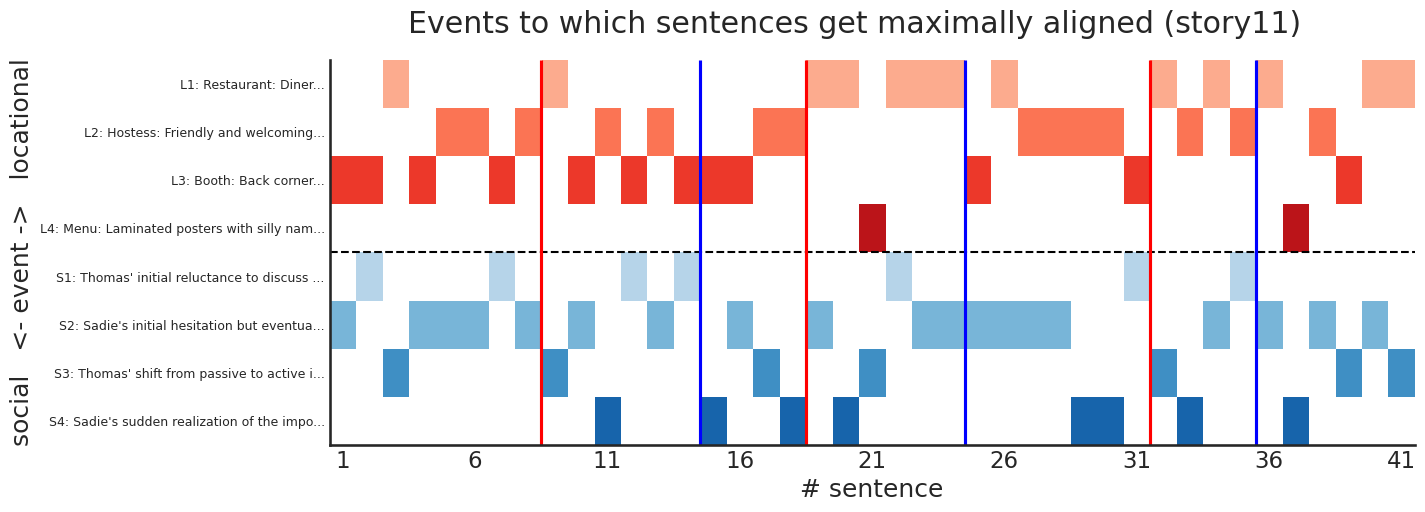

Saved → ../../results/narrative/figs/lane_plot_story11.svg


In [41]:
import matplotlib.colors as mcolors

CONTINUOUS = False   # True = cosine sim heatmap | False = discrete argmax lanes

n_sents = len(sentences)
n_loc   = len(loc_descs)
n_soc   = len(soc_descs)
n_rows  = n_loc + n_soc

lane_matrix = np.zeros((n_rows, n_sents))
if CONTINUOUS:
    # each cell holds the raw cosine similarity between sentence j and event i
    for i in range(n_loc):    lane_matrix[i, :]         = loc_sim[:, i]
    for i in range(n_soc):    lane_matrix[n_loc + i, :] = soc_sim[:, i]
    cmap = 'viridis'
else:
    # each filled cell holds its row index + 1 so each row maps to a unique colormap entry; empty cells stay 0
    for sent_idx, l_ev in enumerate(loc_assign):    lane_matrix[l_ev, sent_idx]        = l_ev + 1
    for sent_idx, s_ev in enumerate(soc_assign):    lane_matrix[n_loc + s_ev, sent_idx] = n_loc + s_ev + 1
    loc_colors = [plt.cm.Reds(0.3 + 0.5 * i / max(n_loc - 1, 1)) for i in range(n_loc)]
    soc_colors = [plt.cm.Blues(0.3 + 0.5 * i / max(n_soc - 1, 1)) for i in range(n_soc)]
    row_colors = loc_colors + soc_colors
    cmap = mcolors.ListedColormap(['white'] + row_colors)

# y-axis labels: prefix L/S so schema is visible without the dashed divider
MAX_LABEL = 38
y_labels = (
    [f"L{i+1}: {loc_descs[i][:MAX_LABEL]}..." for i in range(n_loc)] +
    [f"S{i+1}: {soc_descs[i][:MAX_LABEL]}..." for i in range(n_soc)]
)

fig, ax = plt.subplots(figsize=(14, 5))
plt.suptitle(f'Events to which sentences get maximally aligned (story{STORY_ID})')
ax.set(xlabel='# sentence', xticks=range(0, n_sents, 5), xticklabels=range(1, n_sents + 1, 5),   # 1-indexed labels for readability
       ylabel='social   <- event ->   locational', yticks=range(n_rows), yticklabels=y_labels)
ax.tick_params(axis='y', labelsize=9)

# imshow treats rows as y-axis (row 0 at top); aspect='auto' prevents cell distortion
im = ax.imshow(lane_matrix, aspect='auto', cmap=cmap,
               vmin=0, vmax=(1 if CONTINUOUS else n_rows), interpolation='none')
if CONTINUOUS:
    plt.colorbar(im, ax=ax, label='cosine similarity')

# dashed line between last loc row (index n_loc-1) and first soc row (index n_loc)
ax.axhline(y=n_loc - 0.5, color='black', lw=1.5, ls='--')

# ground-truth event boundaries from story_data columns
story_rows = story_data[story_data['story'] == STORY_ID].reset_index(drop=True)
loc_bounds = story_rows.index[story_rows['locationEvent'].diff().fillna(0) != 0].tolist()
soc_bounds = story_rows.index[story_rows['socialEvent'].diff().fillna(0) != 0].tolist()
# vline at all bounds regardless of schema
for b in loc_bounds:    ax.vlines(b - 0.5, ymin=-0.5, ymax=n_rows - 0.5,  color='red')
for b in soc_bounds:    ax.vlines(b - 0.5, ymin=-0.5, ymax=n_rows - 0.5, color='blue')

PLOT_PATH = f"../../results/narrative/figs/lane_plot_story{STORY_ID}.svg"
plt.savefig(PLOT_PATH, format='svg')
plt.show()
print(f"Saved → {PLOT_PATH}")


### 3. Similarity-based optimal segmenting

3.1 Schema
* Consider this story's schema, drawn from story2schema. Schema = ordered sequence of 4 event questions for this story.

3.2 Sentence-similarity to schema:
* Compute avg cosine similarity between schema and:
    * all sentences.
    * 4 (a number that I can change) random sentences. 
    * 4 chunks of sentences; each of arbitrary size but spanning all sentences overall. so each chunk will have an avged rep which will be used for cosine similarity. Then those 4 vals will be avged.
    * 4 chunks of sentences corresponding to where event boundaries are placed.
* Bar plot the 4 values.

### Notes:
* each bullet gets its own markdown + code block. ensure sufficient comments.
* story2schema drives schema selection (schema_template=0 for social, 1 for locational).
* if this works, the very next step would be to make sure we can loop over stories, and bar plot the avged values. so perhaps, the code right now should be flexible to incorporate that, maybe a loop and break structure?
* Eventually, we'd want better metrics than similarity; for e.g., entropy or predictability..

### 3.1 Schema

Look up this story's schema label from `story2schema`. `schema_template` selects social (0) or locational (1). Encode the label as a **single embedding vector** — this is the schema reference all similarity measures are computed against.

In [42]:
N_CHUNKS = 4         # number of segments to split a story into
schema_template = 0  # 0 = social arc, 1 = locational description

# schema_label is the high-level topic label, e.g. 'break up arc'
schema_label = story2schema[STORY_ID][schema_template]

# encode as a single vector — the semantic centre-of-mass of the schema concept
schema_emb = st_model.encode(schema_label)   # shape: (emb_dim,)

print(f"Story {STORY_ID} — schema: '{schema_label}'")
print(f"schema_emb shape: {schema_emb.shape}")

Story 11 — schema: 'break up arc'
schema_emb shape: (384,)


### 3.2 Continuous schema alignment

For each sentence, compute cosine similarity against the single schema embedding — one line, one concept. Dashed vertical lines show ground-truth event boundaries (red = locational, blue = social).

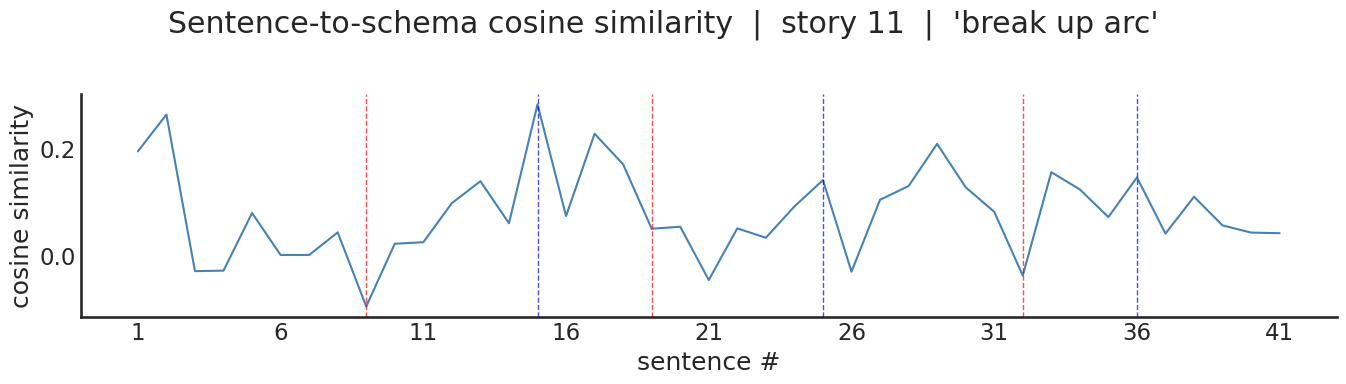

In [43]:
# cosine similarity of each sentence against the single schema embedding → (n_sents,)
sent_schema_sim = cosine_similarity(sent_embs, schema_emb.reshape(1, -1)).squeeze()

x = np.arange(1, len(sentences) + 1)

fig, ax = plt.subplots(figsize=(14, 4))
plt.suptitle(f"Sentence-to-schema cosine similarity  |  story {STORY_ID}  |  '{schema_label}'")

ax.plot(x, sent_schema_sim, color='steelblue', lw=1.5)

# ground-truth event boundaries: red = locational, blue = social
for b in loc_bounds:
    ax.axvline(b + 1, color='red',  lw=1, ls='--', alpha=0.7)
for b in soc_bounds:
    ax.axvline(b + 1, color='blue', lw=1, ls='--', alpha=0.7)

ax.set(xlabel='sentence #', ylabel='cosine similarity',
       xticks=range(1, len(sentences) + 1, 5))
plt.tight_layout()
plt.show()

### 3.3 Avg cosine similarity across 4 sampling strategies

Each strategy produces a set of sentence reps; cosine similarity is computed against the **single schema embedding** and averaged. Random conditions are averaged over `N_PERM` draws to reduce noise.

In [44]:
from sklearn.metrics.pairwise import cosine_similarity

N_PERM = 100   # permutations for random conditions

# choose ground-truth boundary column to match the schema type
gt_col = 'socialEvent' if schema_template == 0 else 'locationEvent'

results = {}

for story_id in sorted(story2text.keys()):
    schema_label_s = story2schema[story_id][schema_template]   # e.g. 'break up arc'
    schema_vec     = st_model.encode(schema_label_s).reshape(1, -1)  # (1, emb_dim)

    s_rows = story_data[story_data['story'] == story_id].reset_index(drop=True)
    sents  = s_rows['storyText'].tolist()
    s_embs = st_model.encode(sents)   # (n_sents, emb_dim)
    n      = len(sents)
    rng    = np.random.default_rng(42)

    def _sim(embs):
        """Avg cosine similarity of a set of embeddings against the schema vector."""
        return cosine_similarity(embs, schema_vec).mean()

    # 1. All sentences: avg similarity across every sentence embedding
    sim_all = _sim(s_embs)

    # 2. N_CHUNKS random sentences: pick N_CHUNKS sentences at random; avg sim; repeat N_PERM times
    rand_sims = [
        _sim(s_embs[rng.choice(n, size=N_CHUNKS, replace=False)])
        for _ in range(N_PERM)
    ]
    sim_rand = np.mean(rand_sims)

    # 3. N_CHUNKS random contiguous chunks: random boundary placement, avg-pool each chunk, avg sim; repeat N_PERM times
    arb_sims = []
    for _ in range(N_PERM):
        cuts  = sorted(rng.choice(range(1, n), size=N_CHUNKS - 1, replace=False).tolist())
        edges = [0] + cuts + [n]
        chunk_reps = np.stack([s_embs[edges[j]:edges[j+1]].mean(axis=0) for j in range(N_CHUNKS)])
        arb_sims.append(_sim(chunk_reps))
    sim_arb = np.mean(arb_sims)

    # 4. Ground-truth event chunks: segment at GT boundaries, avg-pool each chunk, avg sim
    gt_bounds = s_rows.index[s_rows[gt_col].diff().fillna(0) != 0].tolist()
    gt_edges  = [0] + gt_bounds + [n]
    gt_reps   = np.stack([s_embs[gt_edges[j]:gt_edges[j+1]].mean(axis=0) for j in range(len(gt_edges) - 1)])
    sim_gt    = _sim(gt_reps)

    results[story_id] = dict(sims=[sim_all, sim_rand, sim_arb, sim_gt], schema=schema_label_s)
    print(f"Story {story_id} ({schema_label_s}): "
          f"all={sim_all:.3f}  rand={sim_rand:.3f}  arb={sim_arb:.3f}  gt={sim_gt:.3f}")

    break  # remove to run all 16 stories

Story 11 (break up arc): all=0.079  rand=0.081  arb=0.133  gt=0.146


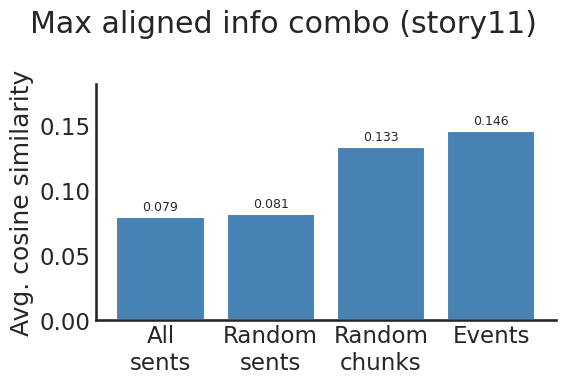

In [45]:
labels = ['All\nsents', 'Random\nsents', 'Random\nchunks', 'Events']
fig, ax = plt.subplots(figsize=(6, 4))
plt.suptitle(f'Max aligned info combo (story{STORY_ID})')

for story_id, res in results.items():
       ax.set(ylabel='Avg. cosine similarity', ylim=(0, max(res['sims']) * 1.25))
       bars = ax.bar(labels, res['sims'], color='steelblue', edgecolor='white')
       ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()